# Tugas Kelompok Materi ke-2 (Model Regresi Cross-Sectional)

## Mahasiswa ke-1: Data Architect & Engineer

### 1. Data Ingestion
Akuisisi dataset dan audit kualitas data awal.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
# Menggunakan path relative karena syntax/main.ipynb selevel dengan dataset/
df = pd.read_csv('../dataset/insurance.csv')
display(df.head())

print("\n--- Data Info ---")
display(df.info())

print("\n--- Data Description ---")
display(df.describe())

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520



--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


None


--- Data Description ---


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


### 2. Feature Encoding
Menerapkan strategi One-Hot Encoding atau Label Encoding pada variabel smoker, sex, dan region.

In [11]:
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()

# Label Encoding for binary categories 'sex' and 'smoker'
le = LabelEncoder()
df_encoded['sex'] = le.fit_transform(df_encoded['sex'])
df_encoded['smoker'] = le.fit_transform(df_encoded['smoker'])

# One-Hot Encoding for 'region' (akan menghasilkan 3 kolom drop_first=True)
df_encoded = pd.get_dummies(df_encoded, columns=['region'], drop_first=True, dtype=int)

display(df_encoded.head())


,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,0,0,1
1,18,1,33.770,1,0,1725.55230,0,1,0
2,28,1,33.000,3,0,4449.46200,0,1,0
3,33,1,22.705,0,0,21984.47061,1,0,0
4,32,1,28.880,0,0,3866.85520,1,0,0


### 3. Outlier Management
Identifikasi dan penanganan nilai ekstrim pada variabel charges dan bmi yang dapat mengganggu garis regresi.

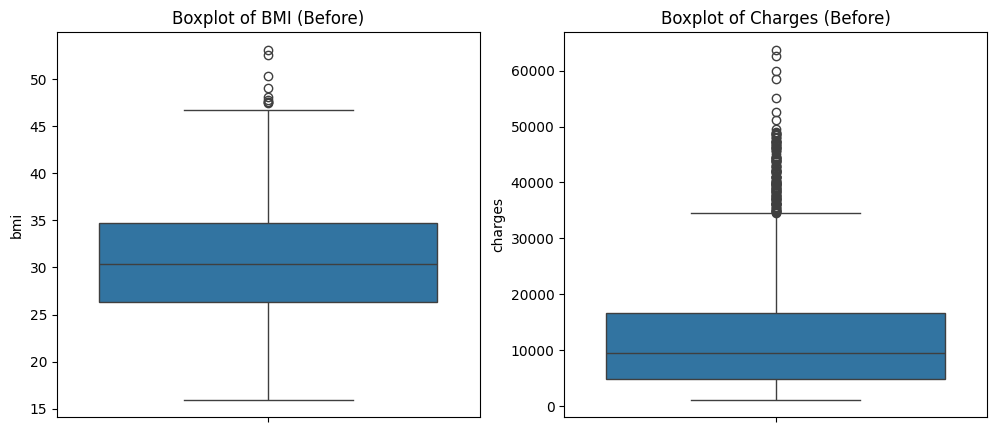

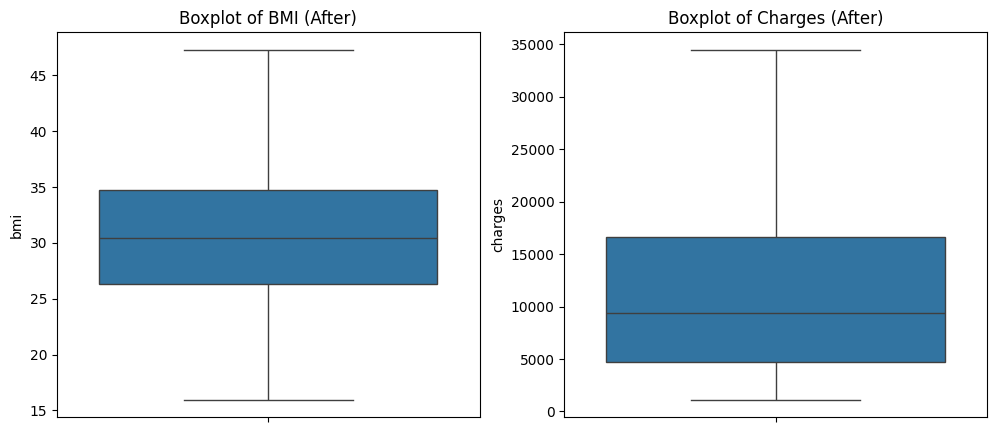

In [12]:
# Visualizing Outliers before handling
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.boxplot(y=df_encoded['bmi'])
plt.title('Boxplot of BMI (Before)')

plt.subplot(1, 2, 2)
sns.boxplot(y=df_encoded['charges'])
plt.title('Boxplot of Charges (Before)')
plt.show()

# Handling Outliers using IQR method (Capping)
def cap_outliers(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    data[column] = np.where(data[column] > upper_bound, upper_bound, data[column])
    data[column] = np.where(data[column] < lower_bound, lower_bound, data[column])
    return data

# Cap Outliers dari BMI dan Charges
df_cleaned = cap_outliers(df_encoded.copy(), 'bmi')
df_cleaned = cap_outliers(df_cleaned, 'charges')

# Validating after capping
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.boxplot(y=df_cleaned['bmi'])
plt.title('Boxplot of BMI (After)')

plt.subplot(1, 2, 2)
sns.boxplot(y=df_cleaned['charges'])
plt.title('Boxplot of Charges (After)')
plt.show()


### 4. Correlation Analysis
Visualisasi hubungan antara gaya hidup (merokok/BMI) terhadap biaya kesehatan.

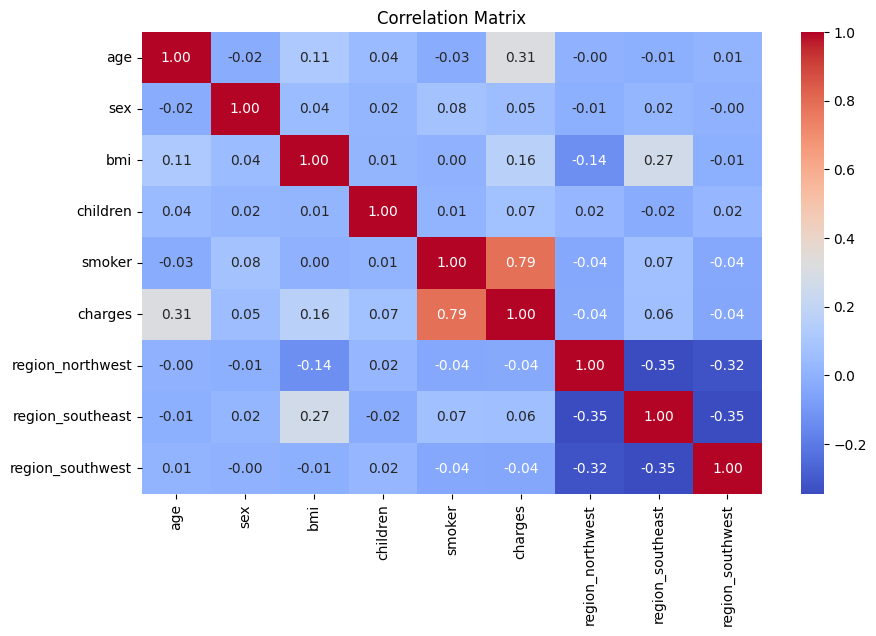

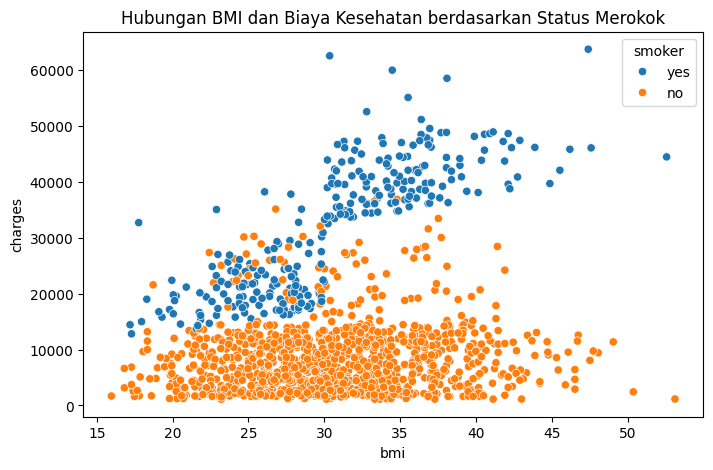

In [13]:
plt.figure(figsize=(10, 6))
sns.heatmap(df_cleaned.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

plt.figure(figsize=(8, 5))
sns.scatterplot(x='bmi', y='charges', hue='smoker', data=df)
plt.title("Hubungan BMI dan Biaya Kesehatan berdasarkan Status Merokok")
plt.show()


### 5. Data Transformation
Melakukan standarisasi atau normalisasi fitur numerik agar model konvergen lebih cepat.

In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
numerical_cols = ['age', 'bmi', 'children']

df_transformed = df_cleaned.copy()
df_transformed[numerical_cols] = scaler.fit_transform(df_transformed[numerical_cols])

display(df_transformed.head())


,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,-1.438764,0,-0.454201,-0.908614,1,16884.92400,0,0,1
1,-1.509965,1,0.515300,-0.078767,0,1725.55230,0,1,0
2,-0.797954,1,0.388125,1.580926,0,4449.46200,0,1,0
3,-0.441948,1,-1.312218,-0.908614,0,21984.47061,1,0,0
4,-0.513149,1,-0.292342,-0.908614,0,3866.85520,1,0,0


## Mahasiswa ke-2: Model Analyst & Strategist

### 1. Model Implementation
Eksperimentasi algoritma regresi (Gradient Boosting Regressor) yang sangat performant untuk asuransi.

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor

# Pisahkan fitur dan target
X = df_transformed.drop('charges', axis=1)
y = df_transformed['charges']

# Split data: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Linear Regression (Sebagai Baseline)
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
y_pred_lin = lin_reg.predict(X_test)

# Gradient Boosting Regressor (GBR)
gbr_reg = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gbr_reg.fit(X_train, y_train)
y_pred_gbr = gbr_reg.predict(X_test)

print("Model berhasil dilatih!")


Model berhasil dilatih!


### 2. Model Assessment
Evaluasi galat menggunakan metrik MAE, RMSE, dan R^2 (Koefisien Determinasi).

In [16]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate_model(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"--- {name} ---")
    print(f"MAE  : {mae:.2f}")
    print(f"RMSE : {rmse:.2f}")
    print(f"R^2  : {r2:.4f}\n")

evaluate_model("Linear Regression", y_test, y_pred_lin)
evaluate_model("Gradient Boosting Regressor", y_test, y_pred_gbr)


--- Linear Regression ---
MAE  : 3316.73
RMSE : 4841.21
R^2  : 0.7841

--- Gradient Boosting Regressor ---
MAE  : 2182.99
RMSE : 4077.77
R^2  : 0.8468



### 3. Explainable AI (XAI)
Menggunakan SHAP untuk membuktikan seberapa besar kenaikan biaya jika seorang nasabah adalah perokok berat dibandingkan nasabah sehat.

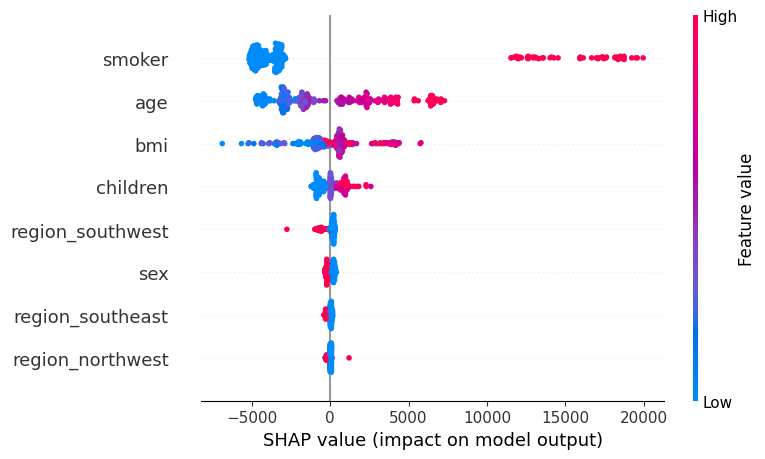

In [17]:
import shap

# Menggunakan model Gradient Boosting Regressor pada SHAP explainer
# TreeExplainer sangat direkomendasikan untuk model tree-based seperti GBR
explainer = shap.TreeExplainer(gbr_reg)
shap_values = explainer.shap_values(X_test)

# Menampilkan SHAP Summary Plot
shap.summary_plot(shap_values, X_test, feature_names=X.columns)


### 4. Policy Simulation
Melakukan uji coba skenario "What-If" menggunakan Data Sintetis:
"Jika seorang nasabah dengan BMI tinggi memutuskan berhenti merokok, berapa estimasi penurunan premi yang bisa diberikan oleh simulator?"

In [18]:
# Skenario Nasabah: Umur 40, Pria, BMI Tinggi (35), Tidak ada anak, Domisili bebas (Southwest)

# Format Fitur Berurutan: 
# ['age', 'sex', 'bmi', 'children', 'smoker', 'region_northwest', 'region_southeast', 'region_southwest']

# Data Awal
age = 40
sex = 1
bmi = 35
children = 0
reg_nw = 0
reg_se = 0
reg_sw = 1

# Create Datasets
sim_data_smoker = pd.DataFrame([[age, sex, bmi, children, 1, reg_nw, reg_se, reg_sw]], columns=X.columns)
sim_data_nonsmoker = pd.DataFrame([[age, sex, bmi, children, 0, reg_nw, reg_se, reg_sw]], columns=X.columns)

# Transform Numerical features via trained Scaler
sim_data_smoker[numerical_cols] = scaler.transform(sim_data_smoker[numerical_cols])
sim_data_nonsmoker[numerical_cols] = scaler.transform(sim_data_nonsmoker[numerical_cols])

# Predict Using GBR Model
pred_smoker = gbr_reg.predict(sim_data_smoker)[0]
pred_nonsmoker = gbr_reg.predict(sim_data_nonsmoker)[0]

print(f"Estimasi Premi (Perokok, BMI Tinggi)    : ${pred_smoker:,.2f}")
print(f"Estimasi Premi (Berhenti Merokok / Non) : ${pred_nonsmoker:,.2f}")
print(f"Estimasi Penurunan Premi yang Diberikan : ${pred_smoker - pred_nonsmoker:,.2f}")


Estimasi Premi (Perokok, BMI Tinggi)    : $34,124.86
Estimasi Premi (Berhenti Merokok / Non) : $5,795.26
Estimasi Penurunan Premi yang Diberikan : $28,329.60
